In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import glob
import sys
from itertools import groupby
from operator import itemgetter
import matplotlib.colors as colors
import seaborn as sns

In [2]:
files = glob.glob("../hdf5_files/*")

In [3]:
files

['../hdf5_files/event_211274458.h5',
 '../hdf5_files/event_256893462.h5',
 '../hdf5_files/event_216741224.h5',
 '../hdf5_files/event_236442324.h5',
 '../hdf5_files/event_242764060.h5',
 '../hdf5_files/event_212636270.h5',
 '../hdf5_files/event_219288990.h5',
 '../hdf5_files/event_239076863.h5',
 '../hdf5_files/event_222684112.h5',
 '../hdf5_files/event_221627323.h5',
 '../hdf5_files/event_98790022.h5',
 '../hdf5_files/event_109687805.h5',
 '../hdf5_files/event_126350302.h5',
 '../hdf5_files/event_222848068.h5',
 '../hdf5_files/event_258517814.h5',
 '../hdf5_files/event_239712228.h5',
 '../hdf5_files/event_211047255.h5',
 '../hdf5_files/event_95818679.h5',
 '../hdf5_files/event_259787063.h5',
 '../hdf5_files/event_131043138.h5',
 '../hdf5_files/event_259870951.h5',
 '../hdf5_files/event_93970574.h5']

In [5]:
cov_fn = glob.glob("results/Covs/*")

In [7]:
cov_fn

['results/Covs/event_222684112_100',
 'results/Covs/event_239076863_100',
 'results/Covs/event_259787063_100',
 'results/Covs/event_131043138_100',
 'results/Covs/event_216741224_100',
 'results/Covs/event_98790022_100',
 'results/Covs/event_258517814_100',
 'results/Covs/event_221627323_100',
 'results/Covs/event_256893462_100',
 'results/Covs/event_259870951_100',
 'results/Covs/event_126350302_100',
 'results/Covs/event_219288990_100',
 'results/Covs/event_236442324_100',
 'results/Covs/event_93970574_100',
 'results/Covs/event_95818679_100',
 'results/Covs/event_239712228_100',
 'results/Covs/event_212636270_100',
 'results/Covs/event_109687805_100',
 'results/Covs/event_211047255_100',
 'results/Covs/event_211274458_100',
 'results/Covs/event_222848068_100']

In [8]:
import re

In [10]:
# Helper function to extract numerical ID
def get_id(filepath):
    match = re.search(r'event_(\d+)', filepath)
    return match.group(1) if match else None

# Map IDs to their paths
dict1 = {get_id(f): f for f in files if get_id(f)}
dict2 = {get_id(f): f for f in cov_fn if get_id(f)}

# Find overlapping IDs sorted numerically
matching_ids = sorted(list(set(dict1.keys()) & set(dict2.keys())), key=int)

# Re-align paths based on matching IDs
sorted_fn= [dict1[eid] for eid in matching_ids]
sorted_cov= [dict2[eid] for eid in matching_ids]

In [11]:
sorted_fn

['../hdf5_files/event_93970574.h5',
 '../hdf5_files/event_95818679.h5',
 '../hdf5_files/event_98790022.h5',
 '../hdf5_files/event_109687805.h5',
 '../hdf5_files/event_126350302.h5',
 '../hdf5_files/event_131043138.h5',
 '../hdf5_files/event_211047255.h5',
 '../hdf5_files/event_211274458.h5',
 '../hdf5_files/event_212636270.h5',
 '../hdf5_files/event_216741224.h5',
 '../hdf5_files/event_219288990.h5',
 '../hdf5_files/event_221627323.h5',
 '../hdf5_files/event_222684112.h5',
 '../hdf5_files/event_222848068.h5',
 '../hdf5_files/event_236442324.h5',
 '../hdf5_files/event_239076863.h5',
 '../hdf5_files/event_239712228.h5',
 '../hdf5_files/event_256893462.h5',
 '../hdf5_files/event_258517814.h5',
 '../hdf5_files/event_259787063.h5',
 '../hdf5_files/event_259870951.h5']

In [12]:
sorted_cov

['results/Covs/event_93970574_100',
 'results/Covs/event_95818679_100',
 'results/Covs/event_98790022_100',
 'results/Covs/event_109687805_100',
 'results/Covs/event_126350302_100',
 'results/Covs/event_131043138_100',
 'results/Covs/event_211047255_100',
 'results/Covs/event_211274458_100',
 'results/Covs/event_212636270_100',
 'results/Covs/event_216741224_100',
 'results/Covs/event_219288990_100',
 'results/Covs/event_221627323_100',
 'results/Covs/event_222684112_100',
 'results/Covs/event_222848068_100',
 'results/Covs/event_236442324_100',
 'results/Covs/event_239076863_100',
 'results/Covs/event_239712228_100',
 'results/Covs/event_256893462_100',
 'results/Covs/event_258517814_100',
 'results/Covs/event_259787063_100',
 'results/Covs/event_259870951_100']

In [24]:
covs = np.empty((len(sorted_cov), 100, 100))
for i in range(len(sorted_cov)):
    cov = np.load(sorted_cov[i]+"/Cov.npy")
    covs[i] = cov

In [25]:
times = []
for fn in sorted_fn:
    times.append(h5py.File(fn).attrs["unix_timestamp"])

In [26]:
times

[np.int64(1356274574),
 np.int64(1358122679),
 np.int64(1361094022),
 np.int64(1371991805),
 np.int64(1388654302),
 np.int64(1393347138),
 np.int64(1473351255),
 np.int64(1473578458),
 np.int64(1474940270),
 np.int64(1479045224),
 np.int64(1481592990),
 np.int64(1483931323),
 np.int64(1484988112),
 np.int64(1485152068),
 np.int64(1498746324),
 np.int64(1501380863),
 np.int64(1502016228),
 np.int64(1519197462),
 np.int64(1520821814),
 np.int64(1522091063),
 np.int64(1522174951)]

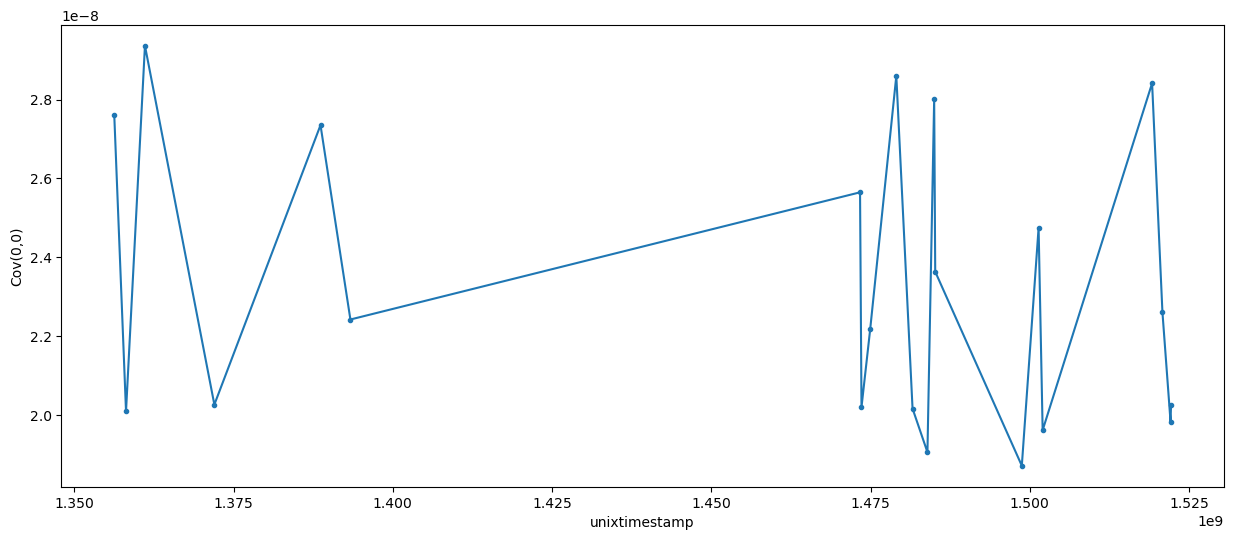

In [36]:
plt.figure(figsize=(15,6))
plt.plot(times, covs[:,0,0])
plt.scatter(times, covs[:,0,0], marker=".")
plt.xlabel("unixtimestamp")
plt.ylabel("Cov(0,0)")
plt.show()

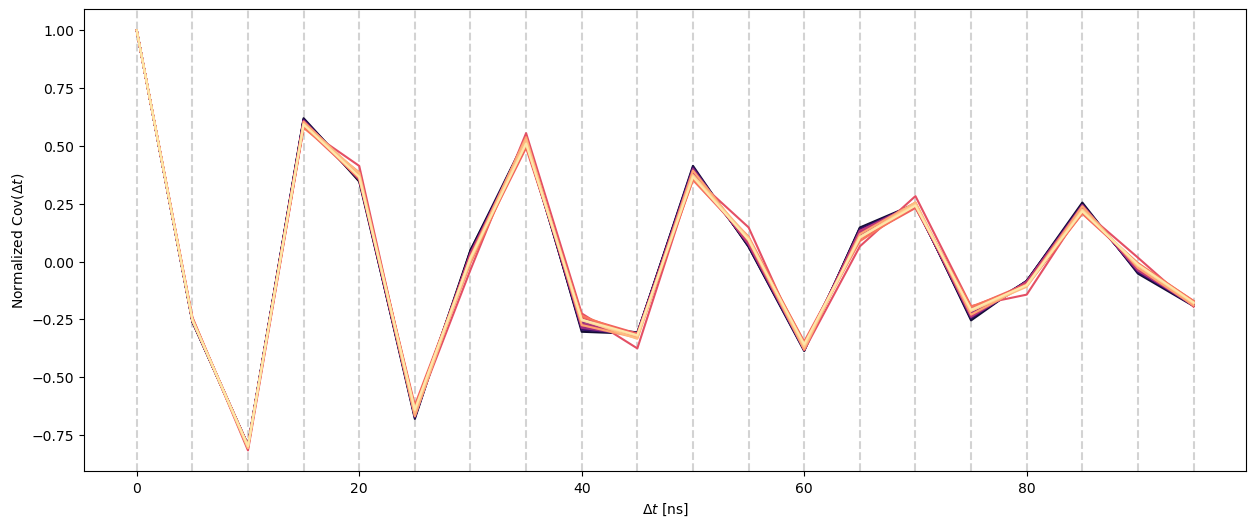

In [52]:
cmap = plt.cm.magma
totn = len(covs)

x = np.arange(20)*5

plt.figure(figsize=(15,6))
for i in range(20):
    plt.axvline(i*5, c="lightgray", linestyle="--")

for i in range(len(covs)):
    color = cmap(i/totn)
    plt.plot(x, covs[i, 0, :20]/covs[i, 0, 0], c=color)

plt.xlabel(r"$\Delta t$ [ns]")
plt.ylabel(r"Normalized Cov($\Delta t$)")

plt.show()

In [44]:
from datetime import datetime, timezone

In [46]:
r_times = []
for time in times:
    r_times.append(datetime.fromtimestamp(time, tz=timezone.utc))

In [47]:
r_times

[datetime.datetime(2012, 12, 23, 14, 56, 14, tzinfo=datetime.timezone.utc),
 datetime.datetime(2013, 1, 14, 0, 17, 59, tzinfo=datetime.timezone.utc),
 datetime.datetime(2013, 2, 17, 9, 40, 22, tzinfo=datetime.timezone.utc),
 datetime.datetime(2013, 6, 23, 12, 50, 5, tzinfo=datetime.timezone.utc),
 datetime.datetime(2014, 1, 2, 9, 18, 22, tzinfo=datetime.timezone.utc),
 datetime.datetime(2014, 2, 25, 16, 52, 18, tzinfo=datetime.timezone.utc),
 datetime.datetime(2016, 9, 8, 16, 14, 15, tzinfo=datetime.timezone.utc),
 datetime.datetime(2016, 9, 11, 7, 20, 58, tzinfo=datetime.timezone.utc),
 datetime.datetime(2016, 9, 27, 1, 37, 50, tzinfo=datetime.timezone.utc),
 datetime.datetime(2016, 11, 13, 13, 53, 44, tzinfo=datetime.timezone.utc),
 datetime.datetime(2016, 12, 13, 1, 36, 30, tzinfo=datetime.timezone.utc),
 datetime.datetime(2017, 1, 9, 3, 8, 43, tzinfo=datetime.timezone.utc),
 datetime.datetime(2017, 1, 21, 8, 41, 52, tzinfo=datetime.timezone.utc),
 datetime.datetime(2017, 1, 23, 6, 

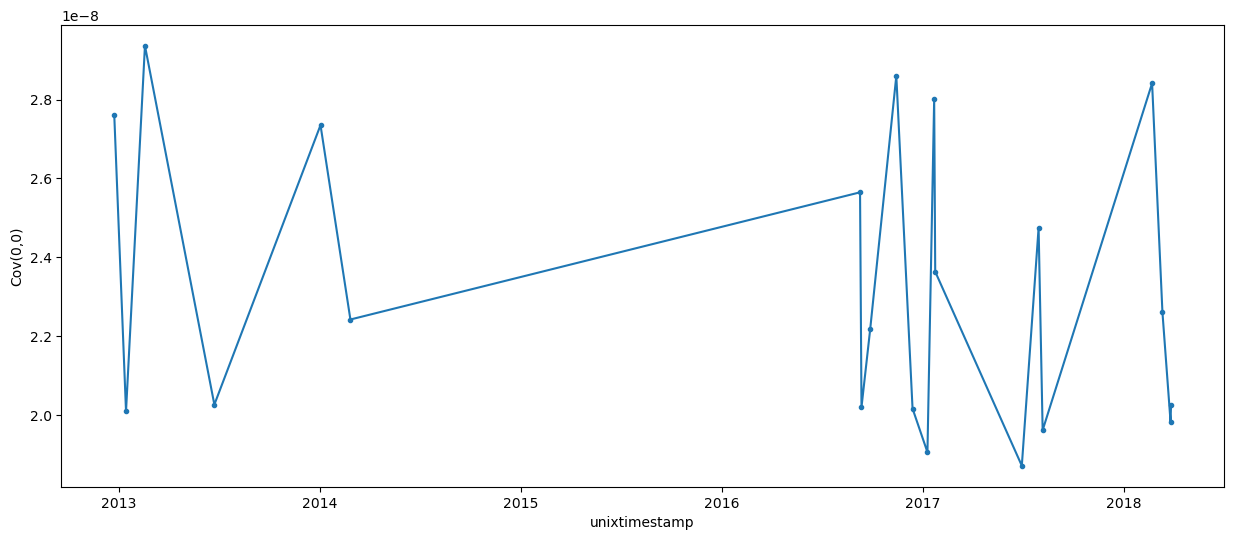

In [48]:
plt.figure(figsize=(15,6))
plt.plot(r_times, covs[:,0,0])
plt.scatter(r_times, covs[:,0,0], marker=".")
plt.xlabel("unixtimestamp")
plt.ylabel("Cov(0,0)")
plt.show()

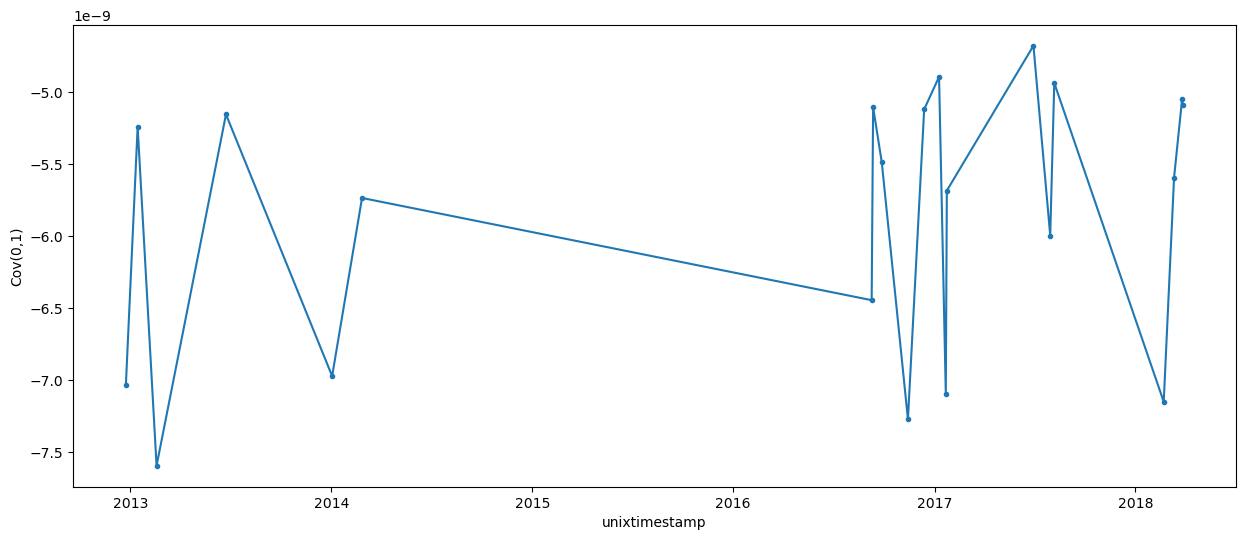

In [50]:
plt.figure(figsize=(15,6))
plt.plot(r_times, covs[:,0,1])
plt.scatter(r_times, covs[:,0,1], marker=".")
plt.xlabel("unixtimestamp")
plt.ylabel("Cov(0,1)")
plt.show()

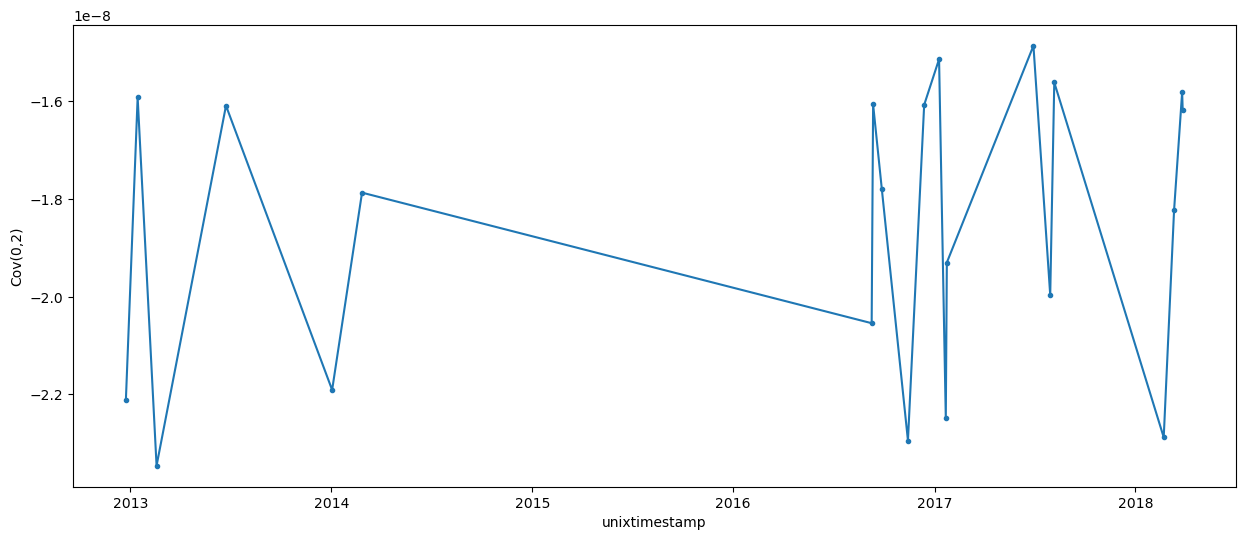

In [51]:
plt.figure(figsize=(15,6))
plt.plot(r_times, covs[:,0,2])
plt.scatter(r_times, covs[:,0,2], marker=".")
plt.xlabel("unixtimestamp")
plt.ylabel("Cov(0,2)")
plt.show()